In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd


In [ ]:


url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"

df = pd.read_csv(url)

df.head()
# len(df)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Do some data cleaning to see if we have any missing data or any duplicated rows of data

In [50]:
#Checking for null values
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [51]:
#Check for duplicates

print(df.duplicated().sum())
duplicates = df[df.duplicated(keep=False)]
print(duplicates)

1
     total_bill  tip     sex smoker   day   time  size
198        13.0  2.0  Female    Yes  Thur  Lunch     2
202        13.0  2.0  Female    Yes  Thur  Lunch     2


In [52]:
df = df.drop_duplicates()
len(df)

243

In [53]:
#Do label encoding for the categorical variables
from sklearn.preprocessing import LabelEncoder  

le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex']) 
df['smoker'] = le.fit_transform(df['smoker'])
df['day'] = le.fit_transform(df['day'])
df['time'] = le.fit_transform(df['time'])
    

In [54]:
X= df[['total_bill', 'size' , 'sex', 'smoker', 'day', 'time']]
y = df['tip']

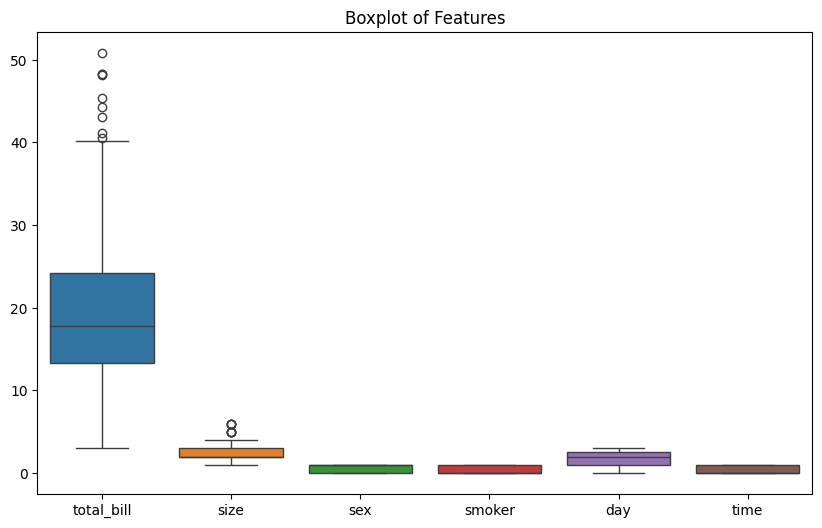

In [55]:
#Check for outliers using boxplot for all features on one graph


# Checking for outliers using boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=X)
plt.title("Boxplot of Features")
plt.show()

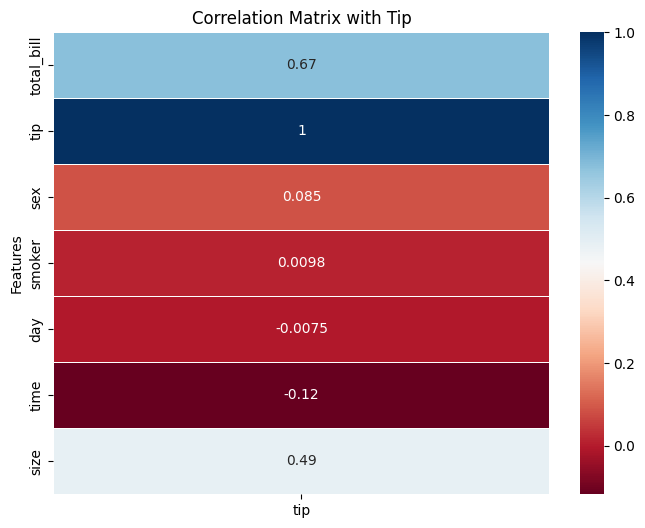

In [56]:
#Check for correlation using heatmap against the target variable 'tip'

df_corr = df.corr(numeric_only=True)[['tip']]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df_corr,
    annot=True,
    cmap="RdBu",
    linewidths=0.5
)

plt.ylabel("Features")
plt.title("Correlation Matrix with Tip")

plt.show()

From the correlation graph the total bill has a high correlation with the tip. So we will use it for the simple linear regression model

In [61]:
#Do simple linear regression to predict tip amount based on total bill amount
#Define the features and target variable...Goal is to predict the tip based of the total bill paid
X = df[['total_bill']]
y = df['tip']

#Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Build the linear regression model

model = LinearRegression()

#Train the model on the training data
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [62]:
#DO prediction on the test set
y_pred = model.predict(X_test)

print("Predicted values:", y_pred)


Predicted values: [3.01322603 1.91053599 2.75776118 2.11011789 3.93230071 4.3184917
 3.84448467 2.43942804 2.51027962 3.42536266 2.86054587 4.03508539
 2.36059319 6.10574768 2.04026423 2.2987228  4.31150633 3.1888581
 2.67693051 2.48433397 3.10004416 3.09605252 2.85555632 1.98837293
 3.10004416 2.78270892 2.06022242 3.55808463 2.66395769 4.01412929
 1.75885374 1.8077513  2.81264621 3.06012777 2.72882181 1.88558825
 3.75766654 2.06720778 2.44741132 3.29763024 2.08417225 2.09814298
 4.83441093 2.06620987 1.78978893 1.34172755 4.19974047 2.90046225
 4.49312587]


In [64]:
#Evaluate the model using mean squared error and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 1.1507520570798668
R-squared: 0.5276979930058592


The model explains approximately 52.8% of the variation in tip amounts using total bill alone.
The limitation is the rest 47% remain unexplained by just using total bill as the X variable.
There is a chance the other variable also affect the btipping behaviour

The Mean Squared Error of 1.15 indicates that prediction errors remain relatively moderate, though the model does not fully capture all factors influencing tip size.

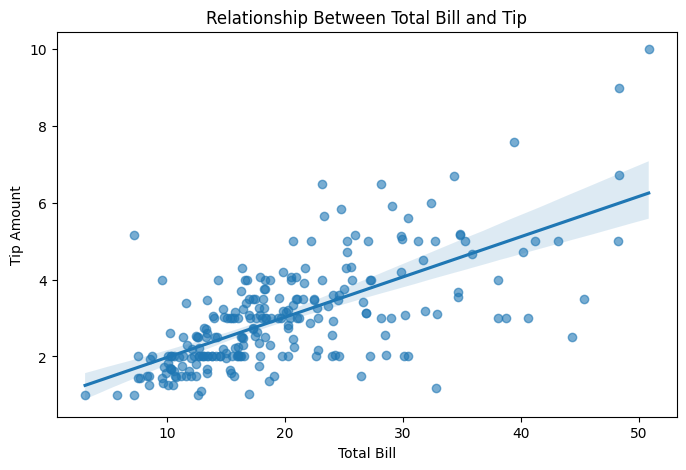

In [66]:
#Visualizing the relationship between total bill and tip using a scatter plot with a regression line
plt.figure(figsize=(8,5))

sns.regplot(
    x='total_bill',
    y='tip',
    data=df,
    scatter_kws={"alpha":0.6}
)

plt.title("Relationship Between Total Bill and Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip Amount")

plt.show()

In [67]:
print("Model Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Model Coefficient: 0.09979095383397454
Intercept: 1.0353693203931391


y^​=0.0998(total_bill)+1.0354

This define our simple regression equation
0.0998 -> For every 1-unit increase in total bill, the predicted tip increases by approximately 0.10 units on average.
1.0354 -> When the tip is 0 the model predict an approximate tip of 1.0354

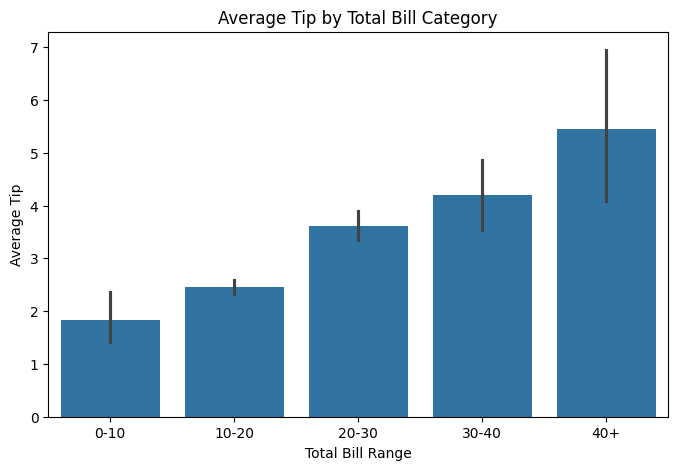

In [68]:
# Create bill categories
df['bill_category'] = pd.cut(
    df['total_bill'],
    bins=[0,10,20,30,40,60],
    labels=['0-10','10-20','20-30','30-40','40+']
)

# Plot average tip by bill category
plt.figure(figsize=(8,5))

sns.barplot(
    x='bill_category',
    y='tip',
    data=df,
    estimator='mean'
)

plt.title("Average Tip by Total Bill Category")
plt.xlabel("Total Bill Range")
plt.ylabel("Average Tip")

plt.show()